# Configuration set-up and variable settings

In this short step we'll set the hardware accelarator (GPU if available), import the libraries needed and set some variables to make easier to check and change them.

In [1]:
#!pip install image-classifiers

In [2]:
import os
import warnings
import ssl

import numpy as np
import matplotlib.pyplot as plt
import cv2
import pandas as pd

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
#from classification_models.tfkeras import Classifiers

import tensorflow as tf
import tensorflow_datasets as tfds
import keras

from keras.models import Sequential
from keras.layers import Input, Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization 
from keras.layers import RandomFlip, RandomRotation, RandomZoom, LeakyReLU, GlobalAveragePooling2D
from keras.optimizers import Adam, SGD
from keras.losses import SparseCategoricalCrossentropy

/home/user/LabSession6-pt1/LabSession6-pt1/Project/PetClassification_CV_Project/venv/lib/python3.12/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/home/user/LabSession6-pt1/LabSession6-pt1/Project/PetClassification_CV_Project/venv/lib/python3.12/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/home/user/LabSession6-pt1/LabSession6-pt1/Project/PetClassification_CV_Project/venv/lib/python3.12/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Pr

In [3]:
tf.get_logger().setLevel('ERROR')
warnings.filterwarnings("ignore")
ssl._create_default_https_context = ssl._create_unverified_context

# Select TensorFlow's backend
os.environ["KERAS_BACKEND"] = "tensorflow"

# Select hardware accelerator (GPU)
#os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
gpu_devices = tf.config.list_physical_devices("GPU")
if gpu_devices:
    details = tf.config.experimental.get_device_details(gpu_devices[0])
    gpu_name = details.get("device_name", "Name not found")
    print(f"Available GPU: {gpu_name}")
else:
    print("No GPU detected.")

print(f"Keras version: {keras.__version__}")

seed = 42
keras.utils.set_random_seed(seed)
np.random.seed(seed)

Available GPU: NVIDIA GeForce GTX 1660 Ti
Keras version: 3.14.0


Some utility function are defined below:

In [4]:
def plot_history(history):
    plt.figure(figsize=(20, 3))
    for i, metric in enumerate(["accuracy", "loss"]):
        plt.subplot(1, 2, i + 1) 
        plt.plot(history.history[metric])
        plt.plot(history.history["val_" + metric])
        plt.title("Model {}".format(metric))
        plt.xlabel("epochs")
        plt.ylabel(metric)
        plt.legend(["train", "val"])


We chose these hyperparameters because:
- **Img shape**: A resolution of 256x256, while being higher than ImageNet's standard (224x224), should help in finding all the details that differentiate cats and dogs races, such as the texture of their fur;
- **Batch size**: Based on [this paper](https://arxiv.org/abs/1609.04836), bigger batche sizes tend to have problems like overfitting;
- **Learning rate**: 1e-3 is the standard value for [Adam optimizer](https://www.intel.com/content/dam/www/public/us/en/ai/documents/1412.6980.pdf) and helps to reach very fast the area where the loss function is lower. Then, the callback ReduceLROnPlateau can refine the search in the area to find lowest point.

In [5]:
IMG_SHAPE = (256, 256) 
BATCH_SIZE = 32
EPOCHS = 150
METRICS = ["accuracy"]

## Optimizer parameters
PATIENCE_STOP = 10
PATIENCE_PLAT = 5
INIT_LR = 1e-3

# Data import, inspection and pre-processing

In this section we'll first import the dataset, then...

## Data import

Import the dataset using tenserflow dataset to have it remotly and to not need to have locally the data. Note that we've used a different split than the original authors. In particular we've used the following splits:
- **Train split**: 80% train + 60% test
- **Validation split**: 20% train + 20% test
- **Test split**: 20% test

wrt the original split proposed by the authors.

In [6]:
dataset_split = ["train[:80%]", "train[80%:]", "test[:60%]", "test[60%:80%]", "test[80%:]"]
(train_split, val_split, extra_train, extra_val, test_data), info = tfds.load(
    "oxford_iiit_pet", 
    split=dataset_split, 
    as_supervised=True, 
    with_info=True
)

train_split = train_split.concatenate(extra_train)
val_split   = val_split.concatenate(extra_val)

I0000 00:00:1778419905.290762   91669 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4146 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660 Ti, pci bus id: 0000:01:00.0, compute capability: 7.5


## Data inspection

Let's check the class distribution in every split to see how the dataset is distributed:

In [7]:
def get_labels(dataset):
    return np.array([label.numpy() for _, label in dataset])

y_train_labels = get_labels(train_split)
y_val_labels   = get_labels(val_split)
y_test_labels  = get_labels(test_data)

print(f"Train samples: {len(y_train_labels)}")
print(f"Val samples:   {len(y_val_labels)}")
print(f"Test samples:  {len(y_test_labels)}")

_, train_count      = np.unique(y_train_labels, return_counts=True)
_, validation_count = np.unique(y_val_labels,   return_counts=True)
_, test_count       = np.unique(y_test_labels,  return_counts=True)

distribution = pd.DataFrame({
    "Class": info.features["label"].names,
    "Train%":      (train_count / len(y_train_labels)) * 100,
    "Validation%": (validation_count / len(y_val_labels)) * 100,
    "Test%":       (test_count / len(y_test_labels)) * 100,
    "Train":      train_count,
    "Validation": validation_count,
    "Test":       test_count,
})
distribution["Total count"] = distribution["Train"] + distribution["Validation"] + distribution["Test"]
distribution = distribution.round(2)

## Print results
print(f"Perfectly balanced dataset distribution if ~={100/len(distribution):.2f}%:")
distribution

Train samples: 5145
Val samples:   1470
Test samples:  734
Perfectly balanced dataset distribution if ~=2.70%:


,Class,Train%,Validation%,Test%,Train,Validation,Test,Total count
0,Abyssinian,2.59,3.06,2.72,133,45,20,198
1,american_bulldog,2.74,2.65,2.72,141,39,20,200
2,american_pit_bull_terrier,2.82,2.11,3.27,145,31,24,200
3,basset_hound,2.66,2.86,2.86,137,42,21,200
4,beagle,2.60,2.65,3.68,134,39,27,200
5,Bengal,2.76,2.79,2.32,142,41,17,200
6,Birman,2.70,2.79,2.72,139,41,20,200
7,Bombay,2.43,2.59,2.86,125,38,21,184
8,boxer,2.64,2.99,2.59,136,44,19,199
9,British_Shorthair,2.90,2.24,2.45,149,33,18,200


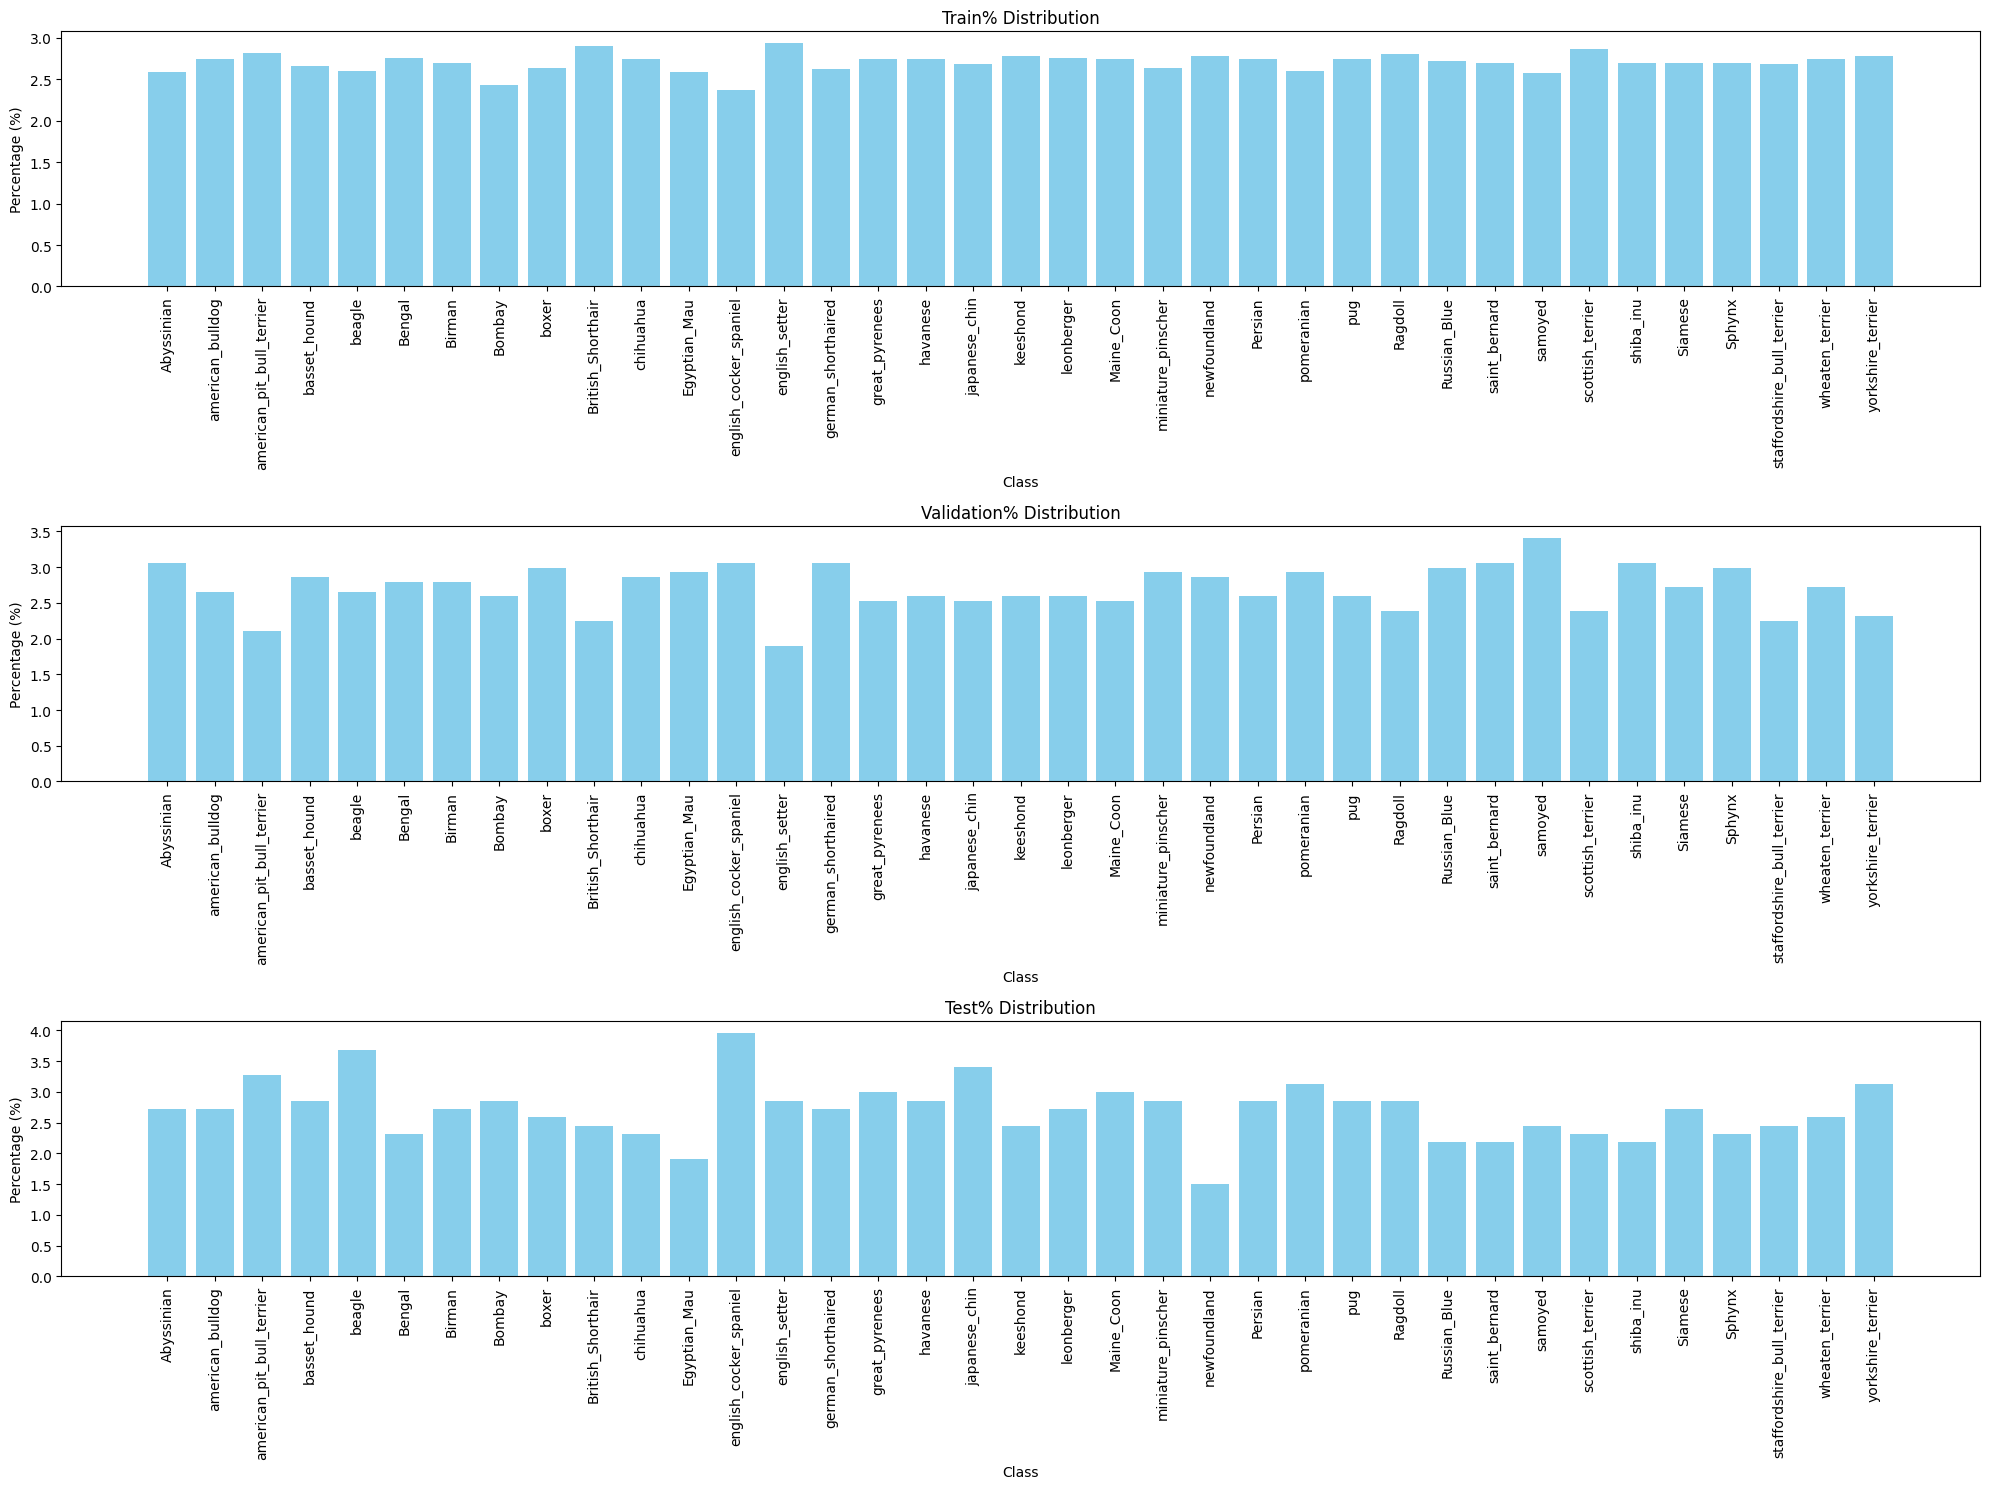

In [8]:
fig, ax = plt.subplots(3, 1, figsize=(20, 15))
ax = ax.flatten()

for idx in range(3):
    ax[idx].bar(distribution["Class"], distribution.iloc[:, idx + 1], color="skyblue")
    ax[idx].set_title(f"{distribution.columns[idx + 1]} Distribution")
    ax[idx].set_xlabel("Class")
    ax[idx].set_ylabel("Percentage (%)")
    ax[idx].set_xticklabels(distribution["Class"], rotation=90)

plt.tight_layout()
plt.show()

We can observe that the class distribution is almost balanced in the train split, so we can ensure that there is no "preference" for the network in learning better a class than another. For the validation and test split the class distribution is not well balanced but this won't effect the learning capability of the network so we can continue with these splits.

Let's get some useful informations for further usage:

In [9]:
labels      = {i: label for i, label in enumerate(info.features["label"].names)}
n_train     = len(y_train_labels)
n_classes   = info.features["label"].num_classes

In [10]:
input_shape = (IMG_SHAPE[0], IMG_SHAPE[1], 3) # 3 channels for RGB
print(f"Input shape: {input_shape}")

Input shape: (256, 256, 3)


## Pre-processing

Finally we do the pre-processig to the data. For ***Train, Validation and Test splits*** the following operations are done:
-   resizing the image to have the desired shape (if the image is smaller a pad of black pixels will be applied)
-   normalization of the pixels in each image to reduce computational effort 

To reach a ~60% of minimum accurac the given training set is not big enough, so we need to increase the number or "image" available for the training phase by **data augmentation to avoid overfitting**. For the ***Test Set*** we apply the following operations:
-   Variations in color brightness, contrast and saturation
-   Random zoom of the image
-   Flipping of the image (left-right)

In [11]:
def dataset_preprocess(img, label):
    img = tf.image.resize_with_pad(img, IMG_SHAPE[0], IMG_SHAPE[1])
    img = tf.cast(img, tf.float32) / 255.0

    return img, label

def train_preprocess(img, label):
    img = tf.image.resize_with_pad(img, IMG_SHAPE[0], IMG_SHAPE[1])
    img = tf.cast(img, tf.float32) / 255.0

    img = tf.image.random_flip_left_right(img)

    ## Color jittering
    img = tf.image.random_brightness(img, 0.2)      # Range of brightness adjustment [-0.2, 0.2]
    img = tf.image.random_contrast(img, 0.8, 1.2)   # Range of contrast adjustment [0.8, 1.2]
    img = tf.image.random_saturation(img, 0.8, 1.2) # Range of saturation adjustment [0.8, 1.2]
    img = tf.image.random_hue(img, 0.05)            # Range of hue adjustment [-0.05, 0.05]
    
    ## Cropping the image: 
    ## 1. resize it to have a "bigger" image of resize_perc
    ## 2. randomly crop. Output image size is the same of the original
    resize_perc = 1.1 
    new_size = [int(IMG_SHAPE[0] * resize_perc), int(IMG_SHAPE[1] * resize_perc)]
    resized_img = tf.image.resize(img, new_size)
    img = tf.image.random_crop(resized_img, size=[IMG_SHAPE[0], IMG_SHAPE[1], 3])
    
    ## to avoid pixel value overflow after color jittering and cropping (i.e. range [0, 1])
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label

Use the above function to define the pre-process pipeline. The pipeline applied at each epoch is defined as follow:
- **shuffling** the data in the training set to avoid model to overfit through breeds since data is stored in batches of breeds
- create **batches** of images to help the model in computing the gradient over a set of images 
- **prefetch** used to prepare next batches (2 in this case) while still running the current one

In [12]:
## Shuffle all the training set (n_train) and apply data augmentation only to the training set
## use the tf.data.AUTOTUNE to optimize the data loading and preprocessing pipeline by parallelizing the operations
train_ds = train_split.shuffle(n_train).map(train_preprocess, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(2)

## Apply the same preprocessing to the validation and test sets, but without data augmentation and shuffling
val_ds   = val_split.map(dataset_preprocess, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(2)
test_ds  = test_data.map(dataset_preprocess, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(2)


We need the input shape for the CNNs to work, which are the dimensions of the images and the number of channels (3) related to the type of image:

In [13]:
input_shape = (IMG_SHAPE[0], IMG_SHAPE[1], 3) # 3 channels for RGB
print(f"Input shape: {input_shape}")

Input shape: (256, 256, 3)


# Task 1


In this first task the goal is to implement a neural network that classifies images of 37 breeds of cats and dogs from the [the Oxford-IIIT Pet Dataset](https://www.robots.ox.ac.uk/~vgg/data/pets/), trying to achieve ~60% of accuracy on the test split. To do so we've followed the following steps:
- Started from a simple model composed of 3 layers with a progressing number of filters to extract bigger features;
- Reached a VGG16-like structure able to better understand the dataset features;
- Worked on the choice of optimizers (SGD or Adam), refined the model structure with GlobalAveragePooling instead of Dense layer and added a Dropout layer to better combat overfitting;
- Introduced callbacks to better refine the learning rate during training;
- Refined hyperparameters such as IMG_SHAPE, BATCH_SIZE and INIT_LR.

## 01. Models implementation 

In this section we illustrate our **starting point** and **key advancements** that bring us to the final model architecture, presented in the next section. 

Only the base model and the final one are shown in this notebook, for the remaining please check the _notebook_ folder. More information in each section: file name and key changes. 

A constant in every file is that the sections 01 and 02 are identical to the ones present in this notebook, so the only difference is the model architecture shown at the end of each file.

### 01.01 Naive Model Implementation

In this section a first, naive, implementation of a model architecture is shown: 

This first model serves as a minimal baseline to establish a reference performance before introducing more complex architectures. We want to verify whether a simpler model can already capture enough structure from the data before adding complexity. The design is kept simple: **3 convolutional blocks** with a **single Conv layer** each, followed by a simple **classification head**.

The filter increase (32 → 64 → 128) follows the standard convention of doubling the number of filters after each pooling step, compensating for the spatial resolution reduction while increasing number of features. The structure of each block is:
-   **Convolutional Layer** with a 3x3 kernel.
-   **BatchNormalization** to normalize to normalize the activation distributions.
-   **MaxPooling2D** sub-sampling to reduce the computational cost for the next layer.




In [14]:
k_size = (3, 3)
model = Sequential([
    
    # Input layer
    Input(shape = input_shape),

    # BLOCK 1
    Conv2D(filters = 32, kernel_size = k_size, activation = "relu", padding = "same"),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    # BLOCK 2
    Conv2D(filters = 64, kernel_size = k_size, activation = "relu", padding = "same"),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    # BLOCK 3
    Conv2D(filters = 128, kernel_size = k_size, activation = "relu", padding = "same"),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    # Classifier
    Flatten(),
    Dense(128, activation="relu"),
    BatchNormalization(),
    Dense(units=n_classes, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    16,777,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 37)             │         4,773 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,876,773 (64.38 MB)

 Trainable params: 16,876,069 (64.38 MB)

 Non-trainable params: 704 (2.75 KB)

The model is optimized using **SGD** with a learning rate of $10^{-3}$. SGD with a fixed learning rate converges more slowly (than other optimizers) but can generalize better.

As **Loss Function**, **Sparse Categorical Crossentropy** is used, since there are more than two class labels provided as integers. More info [here](!https://www.tensorflow.org/api_docs/python/tf/keras/losses/SparseCategoricalCrossentropy).

We use the **EarlyStopping** callback to stop the training if there are no improvements in loss on validation set (within `PATIENCE_STOP` epochs). This is done to prevent overfitting and unnecessary computation. 

In [15]:
opt         = SGD(learning_rate = INIT_LR)
loss_fcn    = SparseCategoricalCrossentropy()
model.compile(loss=loss_fcn, optimizer=opt, metrics=METRICS)

callbacks = [
    ## Restore the best weights of the model based on the validation loss, with a patience of EPOCHS epochs
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE_STOP, restore_best_weights=True, verbose=1),
]

history = model.fit(train_ds, epochs=EPOCHS, validation_data=val_ds, callbacks=callbacks);  

Epoch 1/150
161/161 ━━━━━━━━━━━━━━━━━━━━ 36s 161ms/step - accuracy: 0.0723 - loss: 3.6906 - val_accuracy: 0.0415 - val_loss: 4.5216
Epoch 2/150
161/161 ━━━━━━━━━━━━━━━━━━━━ 17s 95ms/step - accuracy: 0.1213 - loss: 3.2800 - val_accuracy: 0.0551 - val_loss: 5.0694
Epoch 3/150
161/161 ━━━━━━━━━━━━━━━━━━━━ 17s 96ms/step - accuracy: 0.1716 - loss: 3.0746 - val_accuracy: 0.0912 - val_loss: 3.5656
Epoch 4/150
161/161 ━━━━━━━━━━━━━━━━━━━━ 17s 95ms/step - accuracy: 0.1955 - loss: 2.9486 - val_accuracy: 0.1381 - val_loss: 3.1695
Epoch 5/150
161/161 ━━━━━━━━━━━━━━━━━━━━ 17s 96ms/step - accuracy: 0.2190 - loss: 2.8378 - val_accuracy: 0.1660 - val_loss: 3.1502
Epoch 6/150
161/161 ━━━━━━━━━━━━━━━━━━━━ 17s 95ms/step - accuracy: 0.2348 - loss: 2.7691 - val_accuracy: 0.1279 - val_loss: 3.3625
Epoch 7/150
161/161 ━━━━━━━━━━━━━━━━━━━━ 17s 95ms/step - accuracy: 0.2548 - loss: 2.7041 - val_accuracy: 0.1163 - val_loss: 3.5051
Epoch 8/150
161/161 ━━━━━━━━━━━━━━━━━━━━ 17s 95ms/step - accuracy: 0.2713 - loss: 

The test loss is 3.0719, the test accuracy is 0.1975.
Test output shape: (734, 37)


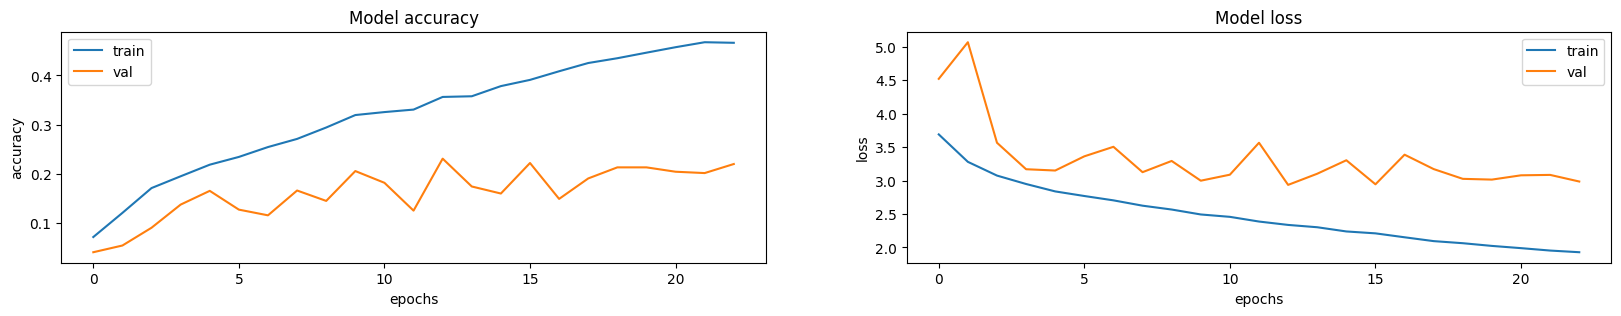

In [16]:
plot_history(history)

test_loss, test_metric = model.evaluate(test_ds, verbose=0)
pred = model.predict(test_ds, verbose=0)
print(f"The test loss is {test_loss:.4f}, the test accuracy is {test_metric:.4f}.")
print("Test output shape: {}".format(pred.shape))

### 01.02 VGG16-Like 


Building upon the baseline, this second iteration introduces a more sophisticated architecture. The design is inspired by the VGG-style philosophy, which emphasizes the use of stacked convolutional layers with small kernels to increase the network's depth while keeping the parameter space manageable.

By stacking two convolutional layers before each pooling step, the network can learn more complex, non-linear features and achieve a larger receptive field compared to a single-layer block.
Due to hardware constraints (GPU RAM), the architecture is scaled to reach a maximum of 256 filters.

A significant shift in this model is the transition from a Flatten layer to GlobalAveragePooling2D (GAP) in the classification head: while Flatten creates a large number of connections (and parameters) between the last feature map and the dense layers, GAP computes the average of each feature map.

This drastic reduction in parameters acts as a structural regularizer, significantly reducing the risk of overfitting while making the model more robust to spatial translations of the input features.

The structure used in all the models from now on is the following:
- **Input layer**: use the previuos computed input shape.
- **BLOCK 1**: first layers to extract low-level features using _32 filters_. 
    - Conv. 1 FLOPs = $2 \times (32 \times 256 \times 256) \times (3 \times 3 \times 3) \approx 113\space MFLOPs$
    - Conv. 2 FLOPs = $2 \times (32 \times 256 \times 256) \times (32 \times 3 \times 3) \approx 1.2\space GFLOPs$
- **BLOCK 2**: use _64 filters_ to capture mid-level features after spatial resolution has been halved by pooling.
    - Conv. 1 FLOPs = $2 \times (64 \times 128 \times 128) \times (32 \times 3 \times 3) \approx 603\space MFLOPs$
    - Conv. 2 FLOPs = $2 \times (64 \times 128 \times 128) \times (64 \times 3 \times 3) \approx 1.2\space GFLOPs$
- **BLOCK 3**: increases to _128 filters_ to learn higher-level.
    - Conv. 1 FLOPs = $2 \times (128 \times 64 \times 64) \times (64 \times 3 \times 3) \approx 603\space MFLOPs$
    - Conv. 2 FLOPs = $2 \times (128 \times 64 \times 64) \times (128 \times 3 \times 3) \approx 1.2\space GFLOPs$
- **BLOCK 4**: uses _256 filters_ to capture class-discriminative features before the classification.
    - Conv. 1 FLOPs = $2 \times (256 \times 32 \times 32) \times (128 \times 3 \times 3) \approx 603\space MFLOPs$
    - Conv. 2 FLOPs = $2 \times (256 \times 32 \times 32) \times (256 \times 3 \times 3) \approx 1.2\space GFLOPs$
- **Classification**: 
    - GAP FLOPs = $256 \times 32 \times 32 \approx 262\space KFLOPs$
    - Dense 1 FLOPs = $2 \times 256 \times 256 \approx 131\space KFLOPs$
    - Dense 2 FLOPs = $2 \times 256 \times 37 \approx 9\space KFLOPs$


Each convolutional block shares the same structure:
-   **2 Conv. Layer**: 3x3 kernels to have less params (18 vs 25) than a 5x5 but with the same receptive field.
-   **BatchNormalization** to normalize to normalize the activation distributions.
-   **MaxPooling2D** sub-sampling to reduce the computational cost for the next layer.

The classification head is composed by:
- **GlobalAveragePooling2D**: it averages each feature map into a single value, drastically reducing the number of params.
- **Dense** + **BatchNormalization**: a fully-connected layer for final feature combination, followed by normalization.
- **Dense**: final output layer for class distribution.

To compute FLOPs we've used the following formula:
-   FLOPs = $2 \times (C_{out} \times H \times W) \times (C_{in} \times H_k \times W_k)$

The file ***1.02_modelImplementation*** in the notebooks directory contains the architecture used.

### 01.03 ADAM

In this iteration the standard Stochastic Gradient Descent (SGD) is replaced by the Adam (Adaptive Moment Estimation) optimizer.

The primary motivation for this change is the need for faster convergence and a more robust "trial and error" workflow: although the final test accuracy could show a slight decrease compared to the SGD-optimized model, using Adam resulted in a significantly reduced training time per epoch and fewer epochs required to reach a stable baseline. **Adam** addresses this by its adaptive learning rates based on first and second moment estimates of the gradients. This makes it significantly more efficient allowing the model to converge faster.

The file ***1.03_modelImplementation*** in the notebooks directory contains the architecture used.

## 02. Final Model Architecture


While the previous architectures established a solid foundation, we observed that the model's loss often reached a "plateau"—a state where the learning rate was too high to allow for further fine-tuning of the weights, causing the accuracy to stagnate.

To address this, we implement the ReduceLROnPlateau callback. This scheduler monitors the validation loss and, if no improvement is seen for a specified number of epochs (`PATIENCE_PLAT`), it automatically reduces the learning rate by a factor (in this case $0.5$).

The introduction of this callback proved to be the most significant performance driver, pushing the test accuracy to ~70%: by halving the learning rate we let the model to perform a more fine-grained convergence, effectively "settling" into the optimal weight configuration.

Also, the final block __Classifier__ presents a further addition with a `Dropout(0.5)` layer to further improve the model's robustness. This technique acts as a powerful regularizer by randomly "dropping" 50% of the neurons during each training step and, by doing so, it prevents co-adaptation, forcing the network to learn redundant and more generalized features rather than relying on specific, noisy patterns.

In [17]:
k_size = (3, 3)
model = Sequential([
    
    # Input layer
    Input(shape = input_shape),

    # BLOCK 1
    Conv2D(filters = 32, kernel_size = k_size, activation = "relu", padding = "same"),
    Conv2D(filters = 32, kernel_size = k_size, activation = "relu", padding = "same"),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    # BLOCK 2
    Conv2D(filters = 64, kernel_size = k_size, activation = "relu", padding = "same"),
    Conv2D(filters = 64, kernel_size = k_size, activation = "relu", padding = "same"),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    # BLOCK 3
    Conv2D(filters = 128, kernel_size = k_size, activation = "relu", padding = "same"),
    Conv2D(filters = 128, kernel_size = k_size, activation = "relu", padding = "same"),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    # BLOCK 4
    Conv2D(filters = 256, kernel_size = k_size, activation = "relu", padding = "same"),
    Conv2D(filters = 256, kernel_size = k_size, activation = "relu", padding = "same"),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    # Classifier
    GlobalAveragePooling2D(),
    Dense(256, activation="relu"),
    BatchNormalization(),
    Dropout(0.5),
    Dense(units = n_classes, activation = "softmax")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 256, 256, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 37)             │         9,509 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,250,501 (4.77 MB)

 Trainable params: 1,249,029 (4.76 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [18]:
opt         = Adam(learning_rate = INIT_LR)
loss_fcn    = SparseCategoricalCrossentropy()
model.compile(loss=loss_fcn, optimizer=opt, metrics=METRICS)

callbacks = [
    ## Restore the best weights of the model based on the validation loss, with a patience of EPOCHS epochs
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE_STOP, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=PATIENCE_PLAT, verbose=1),
]

history = model.fit(train_ds, epochs=EPOCHS, validation_data=val_ds, callbacks=callbacks);  

Epoch 1/150
161/161 ━━━━━━━━━━━━━━━━━━━━ 177s 977ms/step - accuracy: 0.0315 - loss: 4.4616 - val_accuracy: 0.0333 - val_loss: 3.9525 - learning_rate: 0.0010
Epoch 2/150
161/161 ━━━━━━━━━━━━━━━━━━━━ 39s 231ms/step - accuracy: 0.0325 - loss: 4.1676 - val_accuracy: 0.0408 - val_loss: 3.6438 - learning_rate: 0.0010
Epoch 3/150
161/161 ━━━━━━━━━━━━━━━━━━━━ 39s 231ms/step - accuracy: 0.0305 - loss: 4.0856 - val_accuracy: 0.0279 - val_loss: 4.1144 - learning_rate: 0.0010
Epoch 4/150
161/161 ━━━━━━━━━━━━━━━━━━━━ 39s 231ms/step - accuracy: 0.0360 - loss: 3.9532 - val_accuracy: 0.0333 - val_loss: 3.9832 - learning_rate: 0.0010
Epoch 5/150
161/161 ━━━━━━━━━━━━━━━━━━━━ 39s 231ms/step - accuracy: 0.0358 - loss: 3.8687 - val_accuracy: 0.0340 - val_loss: 3.6235 - learning_rate: 0.0010
Epoch 6/150
161/161 ━━━━━━━━━━━━━━━━━━━━ 39s 232ms/step - accuracy: 0.0400 - loss: 3.8140 - val_accuracy: 0.0395 - val_loss: 3.5856 - learning_rate: 0.0010
Epoch 7/150
161/161 ━━━━━━━━━━━━━━━━━━━━ 39s 233ms/step - accur

The test loss is 1.0910, the test accuracy is 0.6907.
Test output shape: (734, 37)


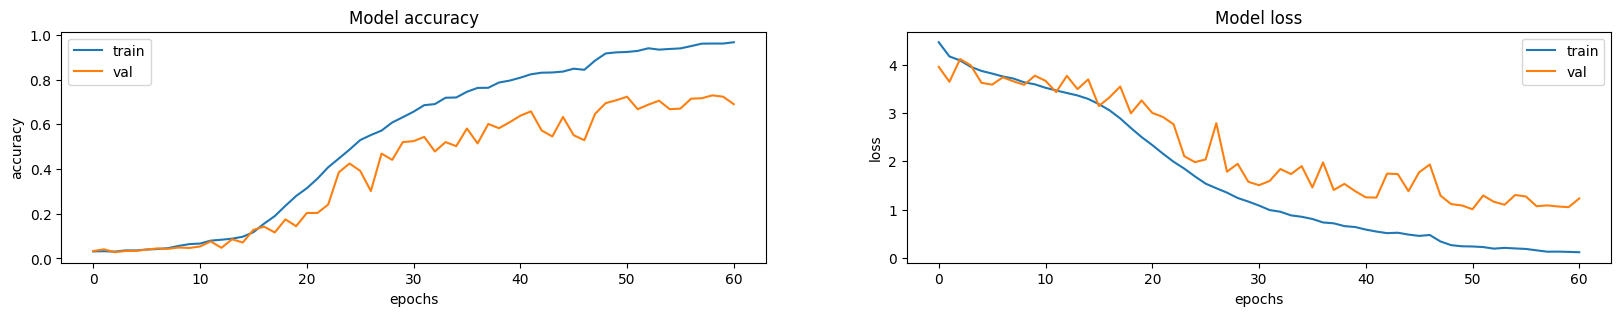

In [19]:
plot_history(history)

test_loss, test_metric = model.evaluate(test_ds, verbose=0)
pred = model.predict(test_ds, verbose=0)
print(f"The test loss is {test_loss:.4f}, the test accuracy is {test_metric:.4f}.")
print("Test output shape: {}".format(pred.shape))

### An experiment on further data augmentation


In order to try to reduce the overfitting we decide to introduce (more) online data augmentation:
- **Random Rotation**: randomly rotate the image in a range of [-30°, +30°]
- **Random Translation**: randomly do translation of the image in a height and widht range of [-10%, +10%]

In [20]:
k_size = (3, 3)
model = Sequential([
    
    # Input layer
    Input(shape = input_shape),

    keras.layers.RandomRotation(factor=30/360, fill_mode='nearest'),
    keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1, fill_mode='nearest'),

    # BLOCK 1
    Conv2D(filters = 32, kernel_size = k_size, activation = "relu", padding = "same"),
    Conv2D(filters = 32, kernel_size = k_size, activation = "relu", padding = "same"),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    # BLOCK 2
    Conv2D(filters = 64, kernel_size = k_size, activation = "relu", padding = "same"),
    Conv2D(filters = 64, kernel_size = k_size, activation = "relu", padding = "same"),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    # BLOCK 3
    Conv2D(filters = 128, kernel_size = k_size, activation = "relu", padding = "same"),
    Conv2D(filters = 128, kernel_size = k_size, activation = "relu", padding = "same"),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    # BLOCK 4
    Conv2D(filters = 256, kernel_size = k_size, activation = "relu", padding = "same"),
    Conv2D(filters = 256, kernel_size = k_size, activation = "relu", padding = "same"),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    # Classifier
    GlobalAveragePooling2D(),
    Dense(256, activation="relu"),
    BatchNormalization(),
    Dropout(0.5),
    Dense(units = n_classes, activation = "softmax")
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_rotation                 │ (None, 256, 256, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 256, 256, 3)    │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 256, 256, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │             

 Total params: 1,250,501 (4.77 MB)

 Trainable params: 1,249,029 (4.76 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [21]:
opt         = Adam(learning_rate = INIT_LR)
loss_fcn    = SparseCategoricalCrossentropy()
model.compile(loss=loss_fcn, optimizer=opt, metrics=METRICS)

callbacks = [
    ## Restore the best weights of the model based on the validation loss, with a patience of EPOCHS epochs
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE_STOP, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=PATIENCE_PLAT, verbose=1),
]

history = model.fit(train_ds, epochs=EPOCHS, validation_data=val_ds, callbacks=callbacks);  

Epoch 1/150
161/161 ━━━━━━━━━━━━━━━━━━━━ 72s 364ms/step - accuracy: 0.0334 - loss: 4.4271 - val_accuracy: 0.0252 - val_loss: 4.0799 - learning_rate: 0.0010
Epoch 2/150
161/161 ━━━━━━━━━━━━━━━━━━━━ 55s 328ms/step - accuracy: 0.0342 - loss: 4.1405 - val_accuracy: 0.0252 - val_loss: 4.2187 - learning_rate: 0.0010
Epoch 3/150
161/161 ━━━━━━━━━━━━━━━━━━━━ 55s 329ms/step - accuracy: 0.0365 - loss: 4.0232 - val_accuracy: 0.0320 - val_loss: 4.0173 - learning_rate: 0.0010
Epoch 4/150
161/161 ━━━━━━━━━━━━━━━━━━━━ 55s 328ms/step - accuracy: 0.0408 - loss: 3.8738 - val_accuracy: 0.0415 - val_loss: 3.7393 - learning_rate: 0.0010
Epoch 5/150
161/161 ━━━━━━━━━━━━━━━━━━━━ 55s 328ms/step - accuracy: 0.0494 - loss: 3.7809 - val_accuracy: 0.0585 - val_loss: 3.6164 - learning_rate: 0.0010
Epoch 6/150
161/161 ━━━━━━━━━━━━━━━━━━━━ 55s 330ms/step - accuracy: 0.0638 - loss: 3.6461 - val_accuracy: 0.0694 - val_loss: 3.5894 - learning_rate: 0.0010
Epoch 7/150
161/161 ━━━━━━━━━━━━━━━━━━━━ 55s 328ms/step - accura

The test loss is 1.3614, the test accuracy is 0.5845.
Test output shape: (734, 37)


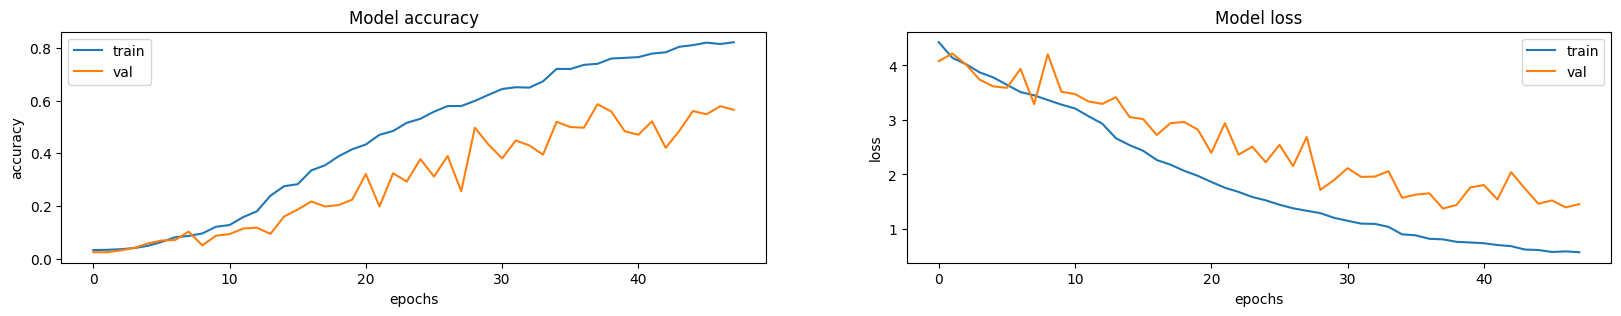

In [22]:
plot_history(history)

test_loss, test_metric = model.evaluate(test_ds, verbose=0)
pred = model.predict(test_ds, verbose=0)
print(f"The test loss is {test_loss:.4f}, the test accuracy is {test_metric:.4f}.")
print("Test output shape: {}".format(pred.shape))

We can observe that the results are worse than the previous model, this probably happens because augmented sampless are "less" representative of the actural test set, introducing noise rather than useful variability.

Another plausible reason is the fact that the CNN architecture is relatively simple: the augmented data could be too complex to train on with the number of epochs or the chosen hyperparameters. The model probably has some difficulty in converging since data change too much between epochs.

# Task 2

In this second task the goal is to to fine-tune a pre-trained ResNet-18 model on the [the Oxford-IIIT Pet Dataset](https://www.robots.ox.ac.uk/~vgg/data/pets/). Using the Keras ResNet-18 model pre-trained on ImageNet-1K. The fine tuning part is divided in 2 parts:
- **First**, fine-tune the ResNet-18 with the same training hyperparameters it's been used for the best model in the first task
- **Second**, tweak the training hyperparameters in order to increase the accuracy on the validation split, trying to obtain a classification accuracy on the validation split between 80 and 90%

In [14]:
import keras_hub

## 05. Fine-Tuning the ResNet-18

In [15]:
resenet18_model = keras_hub.models.ResNetBackbone.from_preset("resnet_18_imagenet")
resenet18_model.summary()

100%|██████████| 836/836 [00:00<00:00, 907kB/s]


100%|██████████| 42.8M/42.8M [00:03<00:00, 13.5MB/s]


Model: "res_net_backbone"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, None,      │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, None,      │      9,408 │ conv1_pad[0][0]   │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, None,      │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, None,      │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, None,      │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, None,      │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block0_1_co… │ (None, None,      │     36,864 │ pool1_pool[0][0]  │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block0_1_bn  │ (None, None,      │        256 │ stack0_block0_1_… │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block0_1_re… │ (None, None,      │          0 │ stack0_block0_1_… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block0_2_co… │ (None, None,      │     36,864 │ stack0_block0_1_… │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block0_2_bn  │ (None, None,      │        256 │ stack0_block0_2_… │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block0_add   │ (None, None,      │          0 │ pool1_pool[0][0], │
│ (Add)               │ None, 64)         │            │ stack0_block0_2_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block0_out   │ (None, None,      │          0 │ stack0_block0_ad… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block1_1_co… │ (None, None,      │     36,864 │ stack0_block0_ou… │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block1_1_bn  │ (None, None,      │        256 │ stack0_block1_1_… │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack0_block1_1_re… │ (None, None,      │          0 │ stack0_block1_1_

 Total params: 11,186,112 (42.67 MB)

 Trainable params: 11,176,512 (42.64 MB)

 Non-trainable params: 9,600 (37.50 KB)

In [18]:
resenet18_model.trainable = False

model = Sequential([

    Input(shape=input_shape),
    
    resenet18_model,

    GlobalAveragePooling2D(),
    Dense(n_classes, activation='softmax')
])

In [20]:
opt         = Adam(learning_rate = INIT_LR)
loss_fcn    = SparseCategoricalCrossentropy()
model.compile(loss=loss_fcn, optimizer=opt, metrics=METRICS)

callbacks = [
    ## Restore the best weights of the model based on the validation loss, with a patience of EPOCHS epochs
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE_STOP, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=PATIENCE_PLAT, verbose=1),
]

history = model.fit(train_ds, epochs=EPOCHS, validation_data=val_ds, callbacks=callbacks);  

Epoch 1/150
161/161 ━━━━━━━━━━━━━━━━━━━━ 179s 1s/step - accuracy: 0.7475 - loss: 1.6113 - val_accuracy: 0.8347 - val_loss: 1.0894 - learning_rate: 0.0010
Epoch 2/150
161/161 ━━━━━━━━━━━━━━━━━━━━ 11s 59ms/step - accuracy: 0.8293 - loss: 0.9832 - val_accuracy: 0.8680 - val_loss: 0.7710 - learning_rate: 0.0010
Epoch 3/150
161/161 ━━━━━━━━━━━━━━━━━━━━ 12s 61ms/step - accuracy: 0.8544 - loss: 0.7625 - val_accuracy: 0.8830 - val_loss: 0.6254 - learning_rate: 0.0010
Epoch 4/150
161/161 ━━━━━━━━━━━━━━━━━━━━ 12s 60ms/step - accuracy: 0.8657 - loss: 0.6424 - val_accuracy: 0.8891 - val_loss: 0.5464 - learning_rate: 0.0010
Epoch 5/150
161/161 ━━━━━━━━━━━━━━━━━━━━ 12s 62ms/step - accuracy: 0.8750 - loss: 0.5602 - val_accuracy: 0.8939 - val_loss: 0.4915 - learning_rate: 0.0010
Epoch 6/150
161/161 ━━━━━━━━━━━━━━━━━━━━ 12s 62ms/step - accuracy: 0.8781 - loss: 0.5189 - val_accuracy: 0.8980 - val_loss: 0.4554 - learning_rate: 0.0010
Epoch 7/150
161/161 ━━━━━━━━━━━━━━━━━━━━ 13s 62ms/step - accuracy: 0.88

The test loss is 0.3448, the test accuracy is 0.8883.
Test output shape: (734, 37)


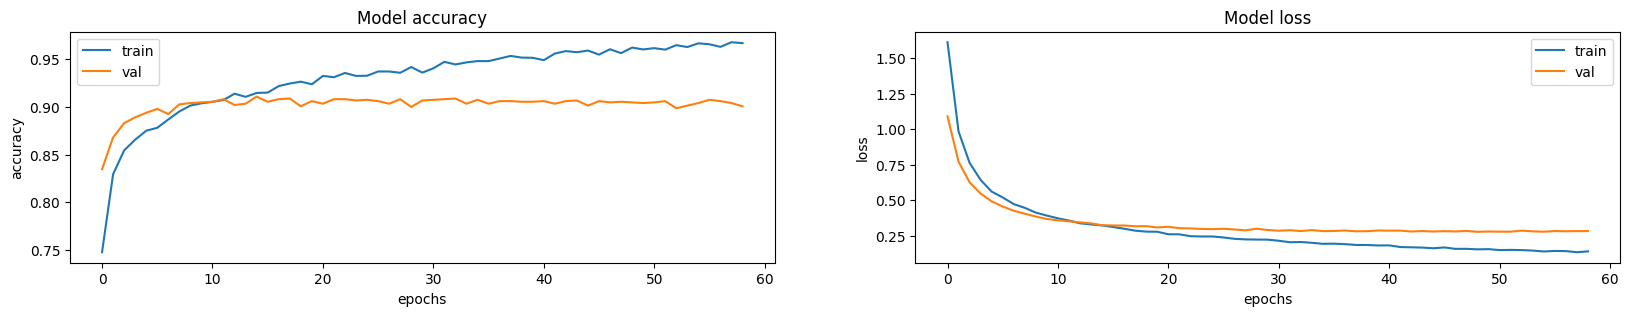

In [21]:
plot_history(history)

test_loss, test_metric = model.evaluate(test_ds, verbose=0)
pred = model.predict(test_ds, verbose=0)

print(f"The test loss is {test_loss:.4f}, the test accuracy is {test_metric:.4f}.")
print("Test output shape: {}".format(pred.shape))

In [22]:
resenet18_model.trainable = True  

UNFREEZE_LR = INIT_LR * 1e-2
print(f"Unfreezing the backbone with a learning rate of {UNFREEZE_LR:.6f} for fine-tuning.")

opt         = Adam(learning_rate = UNFREEZE_LR)
loss_fcn    = SparseCategoricalCrossentropy()
model.compile(loss=loss_fcn, optimizer=opt, metrics=METRICS)

callbacks = [
    ## Restore the best weights of the model based on the validation loss, with a patience of EPOCHS epochs
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE_STOP, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=PATIENCE_PLAT, verbose=1),
]

history = model.fit(train_ds, epochs=EPOCHS, validation_data=val_ds, callbacks=callbacks);  

Unfreezing the backbone with a learning rate of 0.000010 for fine-tuning.
Epoch 1/150
161/161 ━━━━━━━━━━━━━━━━━━━━ 67s 256ms/step - accuracy: 0.7914 - loss: 0.6428 - val_accuracy: 0.8211 - val_loss: 0.5763 - learning_rate: 1.0000e-05
Epoch 2/150
161/161 ━━━━━━━━━━━━━━━━━━━━ 31s 182ms/step - accuracy: 0.8356 - loss: 0.4928 - val_accuracy: 0.8544 - val_loss: 0.4739 - learning_rate: 1.0000e-05
Epoch 3/150
161/161 ━━━━━━━━━━━━━━━━━━━━ 32s 187ms/step - accuracy: 0.8647 - loss: 0.4067 - val_accuracy: 0.8755 - val_loss: 0.4028 - learning_rate: 1.0000e-05
Epoch 4/150
161/161 ━━━━━━━━━━━━━━━━━━━━ 32s 186ms/step - accuracy: 0.8793 - loss: 0.3447 - val_accuracy: 0.8789 - val_loss: 0.3859 - learning_rate: 1.0000e-05
Epoch 5/150
161/161 ━━━━━━━━━━━━━━━━━━━━ 33s 190ms/step - accuracy: 0.8943 - loss: 0.3159 - val_accuracy: 0.8884 - val_loss: 0.3672 - learning_rate: 1.0000e-05
Epoch 6/150
161/161 ━━━━━━━━━━━━━━━━━━━━ 33s 192ms/step - accuracy: 0.9020 - loss: 0.2894 - val_accuracy: 0.8939 - val_loss: 0

The test loss is 0.3231, the test accuracy is 0.8787.
Test output shape: (734, 37)


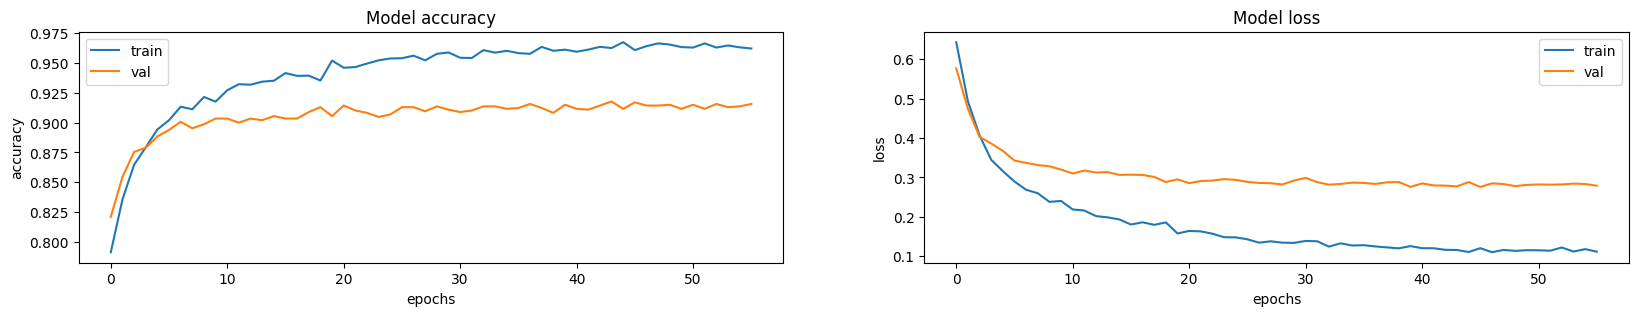

In [23]:
plot_history(history)

test_loss, test_metric = model.evaluate(test_ds, verbose=0)
pred = model.predict(test_ds, verbose=0)

print(f"The test loss is {test_loss:.4f}, the test accuracy is {test_metric:.4f}.")
print("Test output shape: {}".format(pred.shape))

In this last section we try to fine tune the model.

The biggest change is in the learning rate, which is now [lower](https://www.aicuflow.com/docs/tool/training/computer_vision/image_classification/resnet-18) and should converge more precisely to a lower loss function.

The callbacks are also changed in this test to better follow the flow of the model and the reduced number of epochs.

In [26]:
FINE_TUNE_LR = 1e-5

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=FINE_TUNE_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks2 = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=2, verbose=1)
]

print("Inizio Fine-tuning con LR = 1e-5...")
history = model.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    callbacks=callbacks2
)

Inizio Fine-tuning con LR = 1e-5...
Epoch 1/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 51s 228ms/step - accuracy: 0.9672 - loss: 0.1081 - val_accuracy: 0.9136 - val_loss: 0.2842 - learning_rate: 1.0000e-05
Epoch 2/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 32s 182ms/step - accuracy: 0.9670 - loss: 0.1069 - val_accuracy: 0.9109 - val_loss: 0.2875 - learning_rate: 1.0000e-05
Epoch 3/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.9573 - loss: 0.1216
Epoch 3: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
161/161 ━━━━━━━━━━━━━━━━━━━━ 32s 184ms/step - accuracy: 0.9625 - loss: 0.1120 - val_accuracy: 0.9156 - val_loss: 0.2844 - learning_rate: 1.0000e-05
Epoch 4/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 32s 184ms/step - accuracy: 0.9679 - loss: 0.1032 - val_accuracy: 0.9163 - val_loss: 0.2827 - learning_rate: 2.0000e-06
Epoch 5/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 32s 184ms/step - accuracy: 0.9685 - loss: 0.1020 - val_accuracy: 0.9143 - val_loss: 0.2840 - learning_rate: 2.0000e-06
Epoch 6/20
161/

The test loss is 0.3192, the test accuracy is 0.8828.
Test output shape: (734, 37)


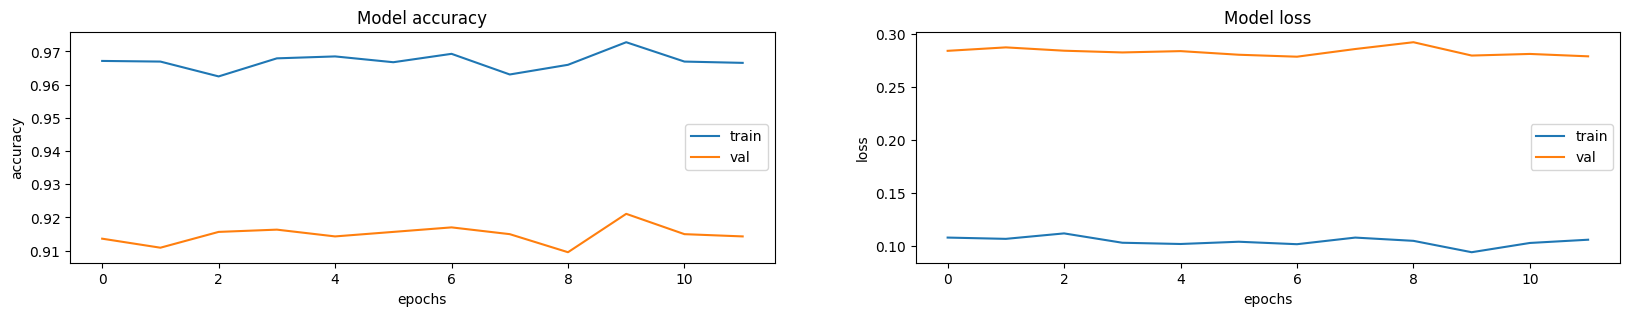

In [27]:
plot_history(history)

test_loss, test_metric = model.evaluate(test_ds, verbose=0)
pred = model.predict(test_ds, verbose=0)

print(f"The test loss is {test_loss:.4f}, the test accuracy is {test_metric:.4f}.")
print("Test output shape: {}".format(pred.shape))